# Chapter 46 — The Art of Radio Images: Visualising Radio Data

!!! info "Before you start"
    **Prerequisites:** Ch 9 (Deconvolution & CLEAN) · Ch 12 (VLA Imaging) · Ch 22 (CMB) ·
    Ch 45 (Radio Galaxies & Source Counts) · **~60 min** · **Intermediate**

A radio image arrives as a 2-D array of numbers — and almost everything that happens next
is a display choice. Those choices are not cosmetic. The colormap you pick can *invent*
structures that don't exist in the data (as "jet" famously does). The stretch you apply
determines whether you see the compact core, the faint extended lobes, *or* both at once.
The beam ellipse you draw (or don't draw) tells the reader the spatial resolution limit
below which nothing is believable. An unlabelled colourbar is a cardinal sin.

This chapter is about making radio images that are simultaneously **beautiful** and
**honest**: every display choice grounded in what is actually in the data.

## Learning goals

By the end of this chapter you will be able to:

- **Explain** why perceptually-uniform colourmaps (`inferno`, `viridis`, `cividis`) avoid
  fabricating structure — and why `jet`/`rainbow` do.
- **Apply** the `radio_norm` stretch ladder — linear, sqrt, log, asinh — and choose the
  right one for the dynamic range at hand, using `dynamic_range`.
- **Clip** display limits robustly with `percentile_limits` and inspect the pixel histogram
  to justify the choice.
- **Annotate** a radio image with a correctly-scaled synthesised-beam ellipse (`add_beam`)
  and a labelled colorbar.
- **Render** all-sky data in an equal-area **Mollweide** projection.
- **Visualise** dynamic spectra (time–frequency waterfalls) with `dynamic_spectrum` and
  choose a stretch that reveals faint drifting features.
- **Overlay** radio contours on an optical/multiwavelength background: the workhorse
  multiwavelength display idiom.


## 1 · The history: from rainbow to perceptual uniformity

The rainbow colormap — `jet` in matplotlib, the default of a generation of scientific
software — ruled scientific visualisation for decades because it felt vivid and natural.
The case against it built slowly, and then suddenly.

**The asinh stretch for photometric images** was introduced by:

> **Lupton, R., Blanton, M. R., Fekete, G., Hogg, D. W., O'Mullane, W., Szalay, A.
> & Wherry, N.** (2004), *Preparing Red-Green-Blue Images from CCD Data*, PASP **116**,
> 133. [DOI 10.1086/382245](https://doi.org/10.1086/382245)

Lupton et al. showed that replacing a hard log cut-off with the smooth $\sinh^{-1}$
function lets you display simultaneously the core of a bright galaxy and its faint
extended halo — exactly the problem a radio astronomer faces with a core plus lobes.
The function is linear near the origin (treating faint pixels faithfully) and
logarithmic at large values (compressing the bright end without clipping).

**Colourblind-safe categorical palettes** became a standard after:

> **Wong, B.** (2011), *Points of view: Color blindness*, Nature Methods **8**, 441.
> [DOI 10.1038/nmeth.1618](https://doi.org/10.1038/nmeth.1618)

Wong's seven-colour palette (the Okabe–Ito set) remains distinguishable to the ~8 % of
the male population with red-green colour vision deficiency. The `jansky` course uses it
as its default line-colour cycle, stored in `plotting.COLORBLIND_CYCLE`.

**The scientific case against rainbow** was made quantitatively by:

> **Borkin, M. A., Gajos, K. Z., Peters, A., Mitsouras, D., Melchionna, S., Rybicki,
> F. J., Feldman, C. L. & Pfister, H.** (2011), *Evaluation of Artery Visualizations for
> Heart Disease Diagnosis*, IEEE Trans. Vis. Comput. Graph. **17**, 2479.
> [DOI 10.1109/TVCG.2011.192](https://doi.org/10.1109/TVCG.2011.192)

and later popularised as *"How Bad is Your Colormap?"* (Niccoli 2014, The Leading Edge).
The core finding: because `jet`'s luminance channel is **non-monotonic** (it peaks in
cyan, dips in green, peaks again in yellow), the human visual system interprets those
luminance steps as real brightness gradients in the data — fabricated features.

**Perceptually-uniform colourmaps** for Python arrived with `viridis` in matplotlib 1.5
(2015), designed by Nathaniel Smith and Stéfan van der Walt and presented at SciPy 2015.
Its siblings `plasma`, `inferno`, and `magma` followed, and `cividis` (Nunez et al.
2018) is their colourblind-robust counterpart. All have monotonically increasing
luminance, so no false features are injected.

The `jansky` helper `recommend_cmap(kind)` encodes these choices: `"sequential"` returns
`"inferno"` (the course default for intensity maps), `"diverging"` returns `"RdBu_r"`
(for signed data like Stokes Q/U/V), `"colorblind"` returns `"cividis"`.


## 2 · The physics of display

### Dynamic range

A radio continuum image of a bright AGN can span five or six orders of magnitude: a core
brightness of several Jy/beam sitting on a noise floor at tens of $\mu$Jy/beam. The
**dynamic range** is defined as

$$
\mathcal{D} \;=\; \frac{S_\mathrm{peak}}{\sigma_\mathrm{rms}}
$$

where $\sigma_\mathrm{rms}$ is the **background** RMS, not the standard deviation of the
whole image (the latter is dominated by the bright sources). A robust estimator is the
**median absolute deviation** (MAD), scaled to be consistent with the Gaussian $\sigma$:

$$
\sigma_\mathrm{robust} \;=\; 1.4826 \times \operatorname{median}\bigl|x - \operatorname{median}(x)\bigr|.
$$

`jansky.plotting.robust_rms` computes this; `dynamic_range` returns $\mathcal{D}$.

### The asinh stretch

The **inverse hyperbolic sine** stretch maps display coordinates $d$ to data values $x$
via

$$
x \;\propto\; \sinh\!\left(\frac{d}{a}\right)
\quad\Longleftrightarrow\quad
d \;\propto\; \sinh^{-1}\!\left(\frac{x}{a}\right),
$$

where the **softening parameter** $a$ (default 0.1 in `radio_norm`) controls the
transition from the linear to the logarithmic regime:

$$
\sinh^{-1}(x/a) \;\approx\; \begin{cases} x/a & x \ll a \\ \ln(2x/a) & x \gg a. \end{cases}
$$

Small $a$ → more compression of the bright end. Large $a$ → nearly linear. Unlike a
pure log stretch, $\sinh^{-1}$ is defined and smooth at zero, so negative noise
fluctuations are handled gracefully.

### The beam as the PSF

Every radio image is convolved with the **synthesised beam** — the point-spread function
of the interferometric array (Chapter 9). No structure smaller than the beam is
independently resolved; anything smaller may be a sidelobe or deconvolution artefact.
Drawing the beam ellipse on every radio image is **mandatory** scientific hygiene:

$$
\theta_\mathrm{beam} \;\sim\; \frac{\lambda}{B_\mathrm{max}},
$$

where $B_\mathrm{max}$ is the longest baseline. For the VLA B-configuration at 3 GHz,
$\theta \sim 2''$. Beam FWHM axes are always labelled in arcseconds; the position angle
is measured from North through East.

### Projections for all-sky data

A flat image of the whole sky necessarily distorts either areas or shapes (Tissot's
theorem). For radio astronomy — where we sum flux to compute luminosity functions, source
counts, or power spectra — **area conservation** is essential. The **Mollweide
projection** is an equal-area pseudo-cylindrical projection: circles of equal solid angle
on the sphere map to equal-area regions in the image, so pixel values are directly
comparable without a correction factor. HEALPix (used in Ch 22) is the pixelisation
scheme designed to have *exactly* equal pixel areas; `healpy.mollview` wraps both.


## Back of the envelope

Before any code: a linear greyscale display can only show as many *distinct* pixel
values as it has grey levels. A radio image's **dynamic range**
$\mathcal{D} = S_\mathrm{peak}/\sigma_\mathrm{rms}$ (§2 above) tells you how many
genuinely different brightness levels are packed into the data, from the faintest
noise fluctuation up to the brightest pixel.

**The question:** a bright quasar core has $S_\mathrm{peak} = 4$ Jy/beam sitting on a
$\sigma_\mathrm{rms} = 40\ \mu$Jy/beam noise floor (a typical deep VLA continuum
image). If you wanted a **linear** greyscale in which no two pixels that differ by more
than the noise ever land on the same displayed level, how many distinct grey levels
would you need?

Rules of the napkin: **decades matter, factors of two don't.** The only formula in play
is $\mathcal{D} = S_\mathrm{peak}/\sigma_\mathrm{rms}$ — work it out on paper first,
then write it as code below.

In [1]:
S_peak = 4.0  # Jy/beam  -- the bright quasar core
sigma_rms = 40e-6  # Jy/beam  -- robust background RMS (a typical deep VLA image)

# Your one line: how many distinct linear grey levels does the dynamic range demand?
grey_levels_guess = None  # <- replace None with an expression in S_peak and sigma_rms

Grade it with the course's envelope checker, `jansky.envelope.check`, introduced in
[Chapter 1](01_what_is_radio_astronomy.ipynb): within half a decade is envelope-grade,
within one decade is the right order of magnitude, further out usually means a units
slip. It never raises, and while your guess is still `None` it just reminds you to fill
it in — so the notebook always runs end-to-end.

In [2]:
from jansky.envelope import check


# The answer is worked in the reveal below -- commit to your own number first.
# The check stores only its base-10 logarithm, so a stray glance can't spoil it.
check(grey_levels_guess, expected_log10=5.0, name="linear grey levels needed", units="levels")

[linear grey levels needed] no guess yet — fill in the cell above, then re-run this one.


False

<details><summary>Reveal — the envelope answer</summary>

$$
\mathcal{D} \;=\; \frac{S_\mathrm{peak}}{\sigma_\mathrm{rms}}
\;=\; \frac{4\ \mathrm{Jy/beam}}{40\times10^{-6}\ \mathrm{Jy/beam}}
\;=\; 1\times10^{5}\ \text{grey levels}.
$$

```python
grey_levels_guess = S_peak / sigma_rms   # = 1.0e5
```

One hundred thousand distinct levels — and an ordinary 8-bit screen (the kind rendering
this notebook) offers only $2^8 = 256$. That's a shortfall of nearly **three decades**:
$\log_2(10^5) \approx 16.6$ *bits* of linear grey level would be needed to show this
image faithfully, and no consumer display, and almost no scientific one, has that many.
Hold that number: it's exactly why every figure below reaches for a **stretch**
(§2, asinh) rather than more bits.

**Where the envelope leaks** (and where this chapter patches it):

- We assumed a **single, uniform** noise level. Real images have spatially varying RMS
  (primary-beam correction, sidelobes near bright sources) — `robust_rms` (§2, Figure 3)
  measures a single representative value from the pixel histogram, which is itself an
  approximation.
- We asked for a **linear** map that never collides two levels — but no display has
  $10^5$ grey steps, so instead of buying more bits we buy a **non-linear stretch**
  (Figure 2): asinh compresses the bright end logarithmically while staying linear near
  the noise, trading exact linearity for visibility of everything at once.
- A fixed grey-level budget spent linearly from $0$ to $S_\mathrm{peak}$ wastes almost
  all of it on pixel values the image never takes — outlier pixels and calibration
  spikes waste it worse still. Figure 3's `percentile_limits` clip is the fix.

</details>

### Turn the knob

The envelope's real power is scaling. Next-generation continuum surveys (e.g. the SKA)
push the noise floor **ten times deeper**, to $\sigma_\mathrm{rms} = 4\ \mu$Jy/beam,
without the bright core getting any fainter. How many grey levels now? Reuse your
expression.

In [3]:
sigma_rms_deep = 4e-6  # Jy/beam -- 10x deeper than before, same 4 Jy/beam core

grey_levels_guess_deep = None  # <- your line again, with the deeper noise floor

check(grey_levels_guess_deep, expected_log10=6.0, name="10x deeper survey, grey levels needed", units="levels")

[10x deeper survey, grey levels needed] no guess yet — fill in the cell above, then re-run this one.


False

<details><summary>Reveal — the scaling answer</summary>

The dynamic range scales inversely with the noise floor:

$$\mathcal{D} \;=\; \frac{S_\mathrm{peak}}{\sigma_\mathrm{rms,deep}} = \frac{4\ \mathrm{Jy/beam}}{4\ \mu\mathrm{Jy/beam}} \;=\; 1.0\times10^{6}.$$

```python
grey_levels_guess_deep = S_peak / sigma_rms_deep   # = 1.0e6 levels, ~20 bits
```

Ten times deeper noise means ten times more levels — $\log_2(10^6) \approx 19.9$ bits
against a screen's 8. Every survey generation widens the gap between what the data
contain and what a linear display can show, which is why the stretch functions in this
chapter are not cosmetic: they are the only way most of the image's information reaches
your eye at all.

</details>

In [4]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse

import astropy.units as u
import astropy.constants as const

from jansky import signals, plotting
from jansky.plotting import (
    use_jansky_style,
    percentile_limits,
    robust_rms,
    dynamic_range,
    radio_norm,
    recommend_cmap,
    add_beam,
    dynamic_spectrum,
    COLORBLIND_CYCLE,
)

use_jansky_style()

# One seeded generator for all synthetic data in this chapter.
rng = signals.rng(seed=4600)

print("Chapter 46 ready — jansky visualisation helpers loaded.")
print(f"  Sequential cmap:  {recommend_cmap('sequential')}")
print(f"  Diverging cmap:   {recommend_cmap('diverging')}")
print(f"  Colourblind cmap: {recommend_cmap('colorblind')}")

Chapter 46 ready — jansky visualisation helpers loaded.
  Sequential cmap:  inferno
  Diverging cmap:   RdBu_r
  Colourblind cmap: cividis


## Figure 1 — Why not jet?

The same synthetic radio field displayed in `jet`, `inferno`, and `viridis`.
Below each image its luminance channel (greyscale brightness perceived by the human eye)
is plotted as a function of normalised data value.  `inferno` and `viridis` are monotone
in luminance; `jet` has a prominent dip near green and a secondary peak in yellow — false
gradients that the eye reads as brightness structure in the data.

The bottom row confirms the verdict of `recommend_cmap`: `jet` is not offered.


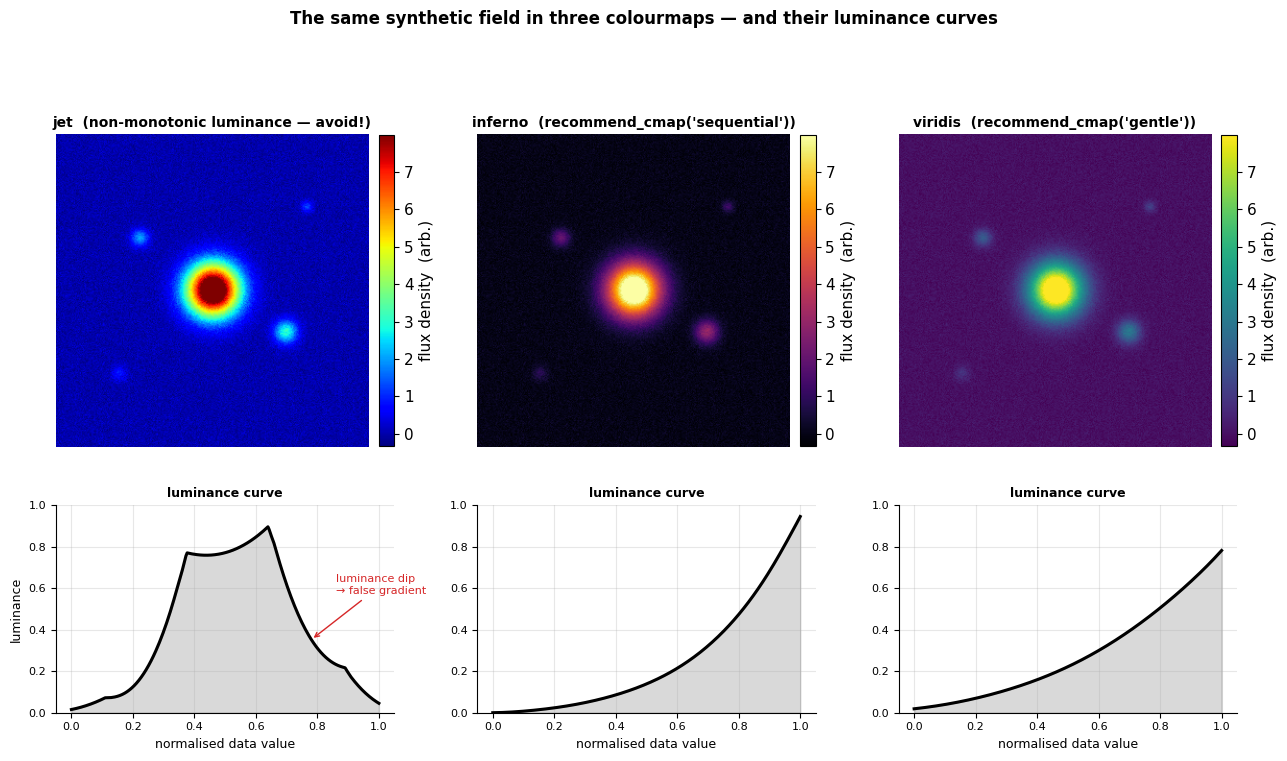

Field dynamic range: 58.3  (peak / robust RMS)


In [5]:
# ─── Synthetic radio field: Gaussian sources on a noise background ───────────
nx, ny = 300, 300
xx, yy = np.meshgrid(np.arange(nx), np.arange(ny))


def gauss2d(cx, cy, sigma, peak):
    return peak * np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma**2))


field = rng.normal(0, 1, (ny, nx)) * 0.15  # noise
field += gauss2d(150, 150, 18, 10.0)  # bright central source
field += gauss2d(220, 110, 8, 3.0)  # secondary sources …
field += gauss2d(80, 200, 6, 2.0)
field += gauss2d(240, 230, 4, 1.2)
field += gauss2d(60, 70, 5, 0.9)


# ─── Luminance conversion (sRGB→perceptual, ITU-R BT.709 coefficients) ───────
def luminance_of_cmap(name, n=256):
    # Return (t, L) where t in [0,1] and L is the perceived luminance.
    cmap = plt.get_cmap(name)
    t = np.linspace(0, 1, n)
    rgba = cmap(t)  # (n, 4) RGBA in [0, 1]
    r, g, b = rgba[:, 0], rgba[:, 1], rgba[:, 2]

    # Linear (un-gamma-corrected) luminance weights (IEC 61966-2-1).
    def un_gamma(c):
        return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

    R, G, B = un_gamma(r), un_gamma(g), un_gamma(b)
    return t, 0.2126 * R + 0.7152 * G + 0.0722 * B


cmaps = ["jet", recommend_cmap("sequential"), recommend_cmap("gentle")]
cmap_labels = [
    "jet  (non-monotonic luminance — avoid!)",
    f"inferno  (recommend_cmap('sequential'))",
    f"viridis  (recommend_cmap('gentle'))",
]

vmin, vmax = percentile_limits(field, 1, 99.5)

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), gridspec_kw={"height_ratios": [3, 1.4]})

for col, (cname, label) in enumerate(zip(cmaps, cmap_labels)):
    ax_img = axes[0, col]
    ax_lum = axes[1, col]

    im = ax_img.imshow(field, cmap=cname, vmin=vmin, vmax=vmax, origin="lower")
    ax_img.set_title(label, fontsize=10, pad=5)
    ax_img.axis("off")
    fig.colorbar(im, ax=ax_img, fraction=0.046, pad=0.03, label="flux density  (arb.)")

    t, L = luminance_of_cmap(cname)
    ax_lum.plot(t, L, lw=2.2, color="k")
    ax_lum.set_ylim(0, 1)
    ax_lum.set_xlabel("normalised data value", fontsize=9)
    if col == 0:
        ax_lum.set_ylabel("luminance", fontsize=9)
    ax_lum.set_title("luminance curve", fontsize=9)
    ax_lum.tick_params(labelsize=8)

    # Fill under the curve so the non-monotonicity jumps out.
    ax_lum.fill_between(t, L, alpha=0.15, color="k")

    # Mark the dip for jet.
    if cname == "jet":
        dip_i = np.argmin(L[100:200]) + 100
        ax_lum.annotate(
            "luminance dip\n→ false gradient",
            xy=(t[dip_i], L[dip_i]),
            xytext=(t[dip_i] + 0.08, L[dip_i] + 0.22),
            arrowprops=dict(arrowstyle="->", color="tab:red"),
            color="tab:red",
            fontsize=8,
        )

fig.suptitle(
    "The same synthetic field in three colourmaps — and their luminance curves",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)
fig.tight_layout()
plt.savefig("/tmp/ch46_fig1_colormaps.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Field dynamic range: {dynamic_range(field):.1f}  (peak / robust RMS)")

## Figure 2 — The stretch ladder on a real radio galaxy (M87 / Virgo A)

We fetch a $0.12°\times0.12°$ VLASS cutout of **M87** (Virgo A) — one of the sky's most
studied radio sources, a FR I jet at only 16.4 Mpc — from the
[NRAO HiPS service](https://archive.nrao.edu/archive/HiPS/) and display it with
four stretches via `radio_norm`.

**Linear** stretch: the bright core saturates the display; the lobes are invisible.
**Sqrt**: the core is still dominant.
**Log**: faint structure appears but noise fluctuations near zero create artefacts.
**Asinh** (the radio standard): core *and* lobes are simultaneously legible, and
negative noise pixels are handled gracefully — no hard clip at zero.

If the network is unavailable the cell falls back to a synthetic twin-lobe radio galaxy
(a central bright Gaussian + two offset fainter Gaussians + Gaussian noise).


VLASS fetch failed (AttributeError): 500 Internal Server Error
Using synthetic twin-lobe radio galaxy fallback.
Synthetic fallback: shape (512, 512),  DR = 544


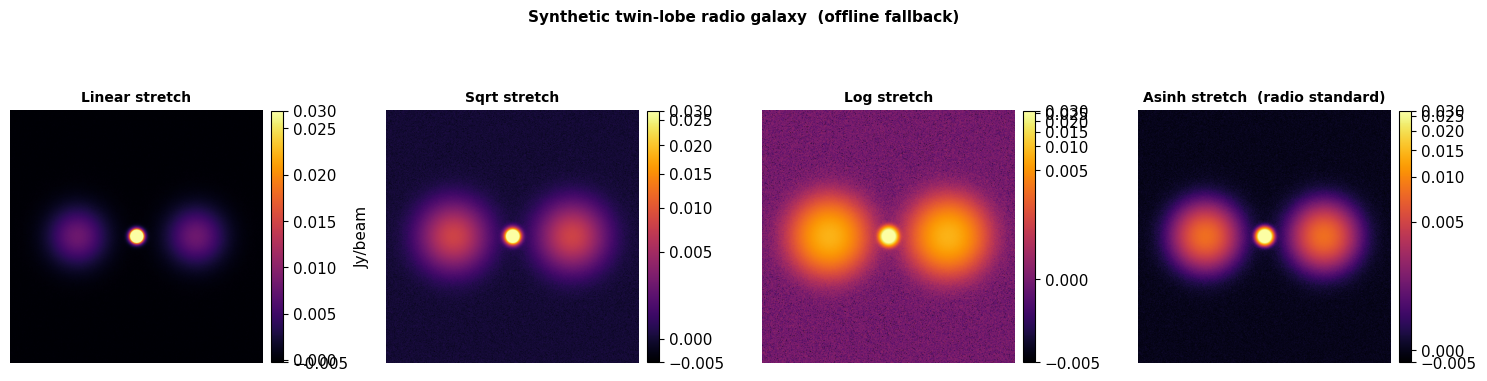


dynamic_range(img)  = 544.1
robust_rms(img)     = 1.842e-04  Jy/beam
peak(img)           = 1.002e-01  Jy/beam
A linear stretch at DR = 544 compresses all the faint emission into <0.01% of the colour range.


In [6]:
# ─── Fetch M87 from VLASS HiPS (with deterministic offline fallback) ──────────
VLASS_HIPS = "NRAO/P/VLASS-Quicklook-MedianStack"
M87_RA_DEG = 187.70593  # hardcoded — no name resolver
M87_DEC_DEG = +12.39112
_FETCH_OK = False

try:
    from astroquery.hips2fits import hips2fits
    from astropy.coordinates import SkyCoord

    coord = SkyCoord(ra=M87_RA_DEG * u.deg, dec=M87_DEC_DEG * u.deg, frame="icrs")
    hdu_list = hips2fits.query(
        hips=VLASS_HIPS,
        width=512,
        height=512,
        fov=0.12 * u.deg,
        projection="SIN",
        ra=coord.ra,
        dec=coord.dec,
        format="fits",
    )
    img_raw = hdu_list[0].data.astype(float)
    if np.all(np.isnan(img_raw)):
        raise ValueError("All-NaN tile returned — falling back to synthetic image.")
    img = img_raw
    img_label = "M87 / Virgo A  (VLASS 2–4 GHz, NRAO HiPS)"
    _FETCH_OK = True
    print(f"VLASS fetch OK:  shape {img.shape},  DR = {dynamic_range(img):.0f}")

except Exception as _e:
    print(f"VLASS fetch failed ({type(_e).__name__}): {_e}")
    print("Using synthetic twin-lobe radio galaxy fallback.")

if not _FETCH_OK:
    # Synthetic core + two lobes on a Gaussian noise background.
    _rng_s = np.random.default_rng(46)
    ny_s, nx_s = 512, 512
    xs, ys = np.meshgrid(np.arange(nx_s), np.arange(ny_s))
    cx, cy = nx_s // 2, ny_s // 2

    def _g(cx_, cy_, s_, p_):
        return p_ * np.exp(-((xs - cx_) ** 2 + (ys - cy_) ** 2) / (2 * s_**2))

    img = _rng_s.normal(0, 1e-4, (ny_s, nx_s))
    img += _g(cx, cy, 8, 0.10)  # compact core  (Jy/beam scale)
    img += _g(cx - 120, cy, 40, 0.008)  # western lobe
    img += _g(cx + 120, cy, 40, 0.008)  # eastern lobe
    img_label = "Synthetic twin-lobe radio galaxy  (offline fallback)"
    print(f"Synthetic fallback: shape {img.shape},  DR = {dynamic_range(img):.0f}")

# ─── Four-panel stretch comparison ───────────────────────────────────────────
stretches = ["linear", "sqrt", "log", "asinh"]
stretch_titles = {
    "linear": "Linear stretch",
    "sqrt": "Sqrt stretch",
    "log": "Log stretch",
    "asinh": "Asinh stretch  (radio standard)",
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4.4))
for ax, stretch in zip(axes, stretches):
    norm = radio_norm(img, stretch=stretch, low=0.5, high=99.8, asinh_a=0.05)
    im = ax.imshow(img, norm=norm, cmap=recommend_cmap("sequential"), origin="lower")
    ax.set_title(stretch_titles[stretch], fontsize=10)
    ax.axis("off")
    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.03,
        label="Jy/beam" if ax is axes[0] else "",
        orientation="vertical",
    )

fig.suptitle(img_label, fontsize=11, fontweight="bold")
fig.tight_layout()
plt.savefig("/tmp/ch46_fig2_stretches.png", dpi=150, bbox_inches="tight")
plt.show()

dr = dynamic_range(img)
rms = robust_rms(img)
pk = np.nanmax(img)
print(f"\ndynamic_range(img)  = {dr:.1f}")
print(f"robust_rms(img)     = {rms:.3e}  Jy/beam")
print(f"peak(img)           = {pk:.3e}  Jy/beam")
print(
    f"A linear stretch at DR = {dr:.0f} compresses all the faint emission into <0.01% of the colour range."
)

## Figure 3 — Percentile clipping and the pixel histogram

Clipping the display range to the 1st–99.5th percentiles (via `percentile_limits`)
concentrates the colour scale on the emission of interest and discards the outlier
pixels that would otherwise eat the entire range.  The pixel histogram makes the
effect transparent: the clip limits are vertical lines; everything outside is shown at
the extreme colours.


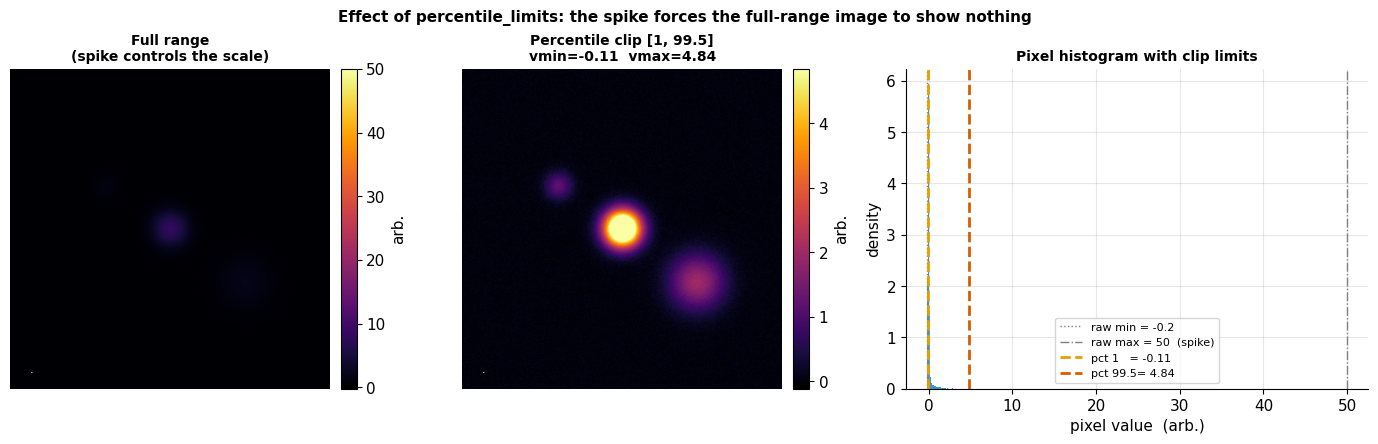

Full range:         vmin = -0.212,  vmax = 50.0
Percentile [1,99.5]: vmin = -0.112,  vmax = 4.838
The spike at pixel (15,20) = 50.0 is 10× the 99.5th percentile.


In [7]:
# ─── Percentile clipping demo ────────────────────────────────────────────────
# Build a high-DR synthetic image with a very bright artefact spike.
_rng_c = np.random.default_rng(4601)
ny_c, nx_c = 300, 300
_xs, _ys = np.meshgrid(np.arange(nx_c), np.arange(ny_c))
_cx, _cy = nx_c // 2, ny_c // 2

img_clip = _rng_c.normal(0, 1, (ny_c, nx_c)) * 0.05
img_clip += 8.0 * np.exp(-((_xs - _cx) ** 2 + (_ys - _cy) ** 2) / (2 * 12**2))
img_clip += 2.0 * np.exp(-((_xs - _cx - 70) ** 2 + (_ys - _cy + 50) ** 2) / (2 * 18**2))
img_clip += 1.2 * np.exp(-((_xs - _cx + 60) ** 2 + (_ys - _cy - 40) ** 2) / (2 * 9**2))
# Inject a fake spike (calibration artefact / sidelobe):
img_clip[15, 20] = 50.0

vmin_raw = np.nanmin(img_clip)
vmax_raw = np.nanmax(img_clip)
vmin_p, vmax_p = percentile_limits(img_clip, 1, 99.5)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1, 1.3]})

# Full range
im0 = axes[0].imshow(
    img_clip, vmin=vmin_raw, vmax=vmax_raw, cmap=recommend_cmap("sequential"), origin="lower"
)
axes[0].set_title("Full range\n(spike controls the scale)", fontsize=10)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03, label="arb.")

# Percentile clip
im1 = axes[1].imshow(
    img_clip, vmin=vmin_p, vmax=vmax_p, cmap=recommend_cmap("sequential"), origin="lower"
)
axes[1].set_title(f"Percentile clip [1, 99.5]\nvmin={vmin_p:.2f}  vmax={vmax_p:.2f}", fontsize=10)
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03, label="arb.")

# Histogram
finite_vals = img_clip[np.isfinite(img_clip)].ravel()
axes[2].hist(
    finite_vals,
    bins=80,
    color=COLORBLIND_CYCLE[0],
    alpha=0.75,
    density=True,
    range=(np.percentile(finite_vals, 0.5), np.percentile(finite_vals, 99.9)),
)
axes[2].axvline(vmin_raw, color="0.5", lw=1.0, ls=":", label=f"raw min = {vmin_raw:.1f}")
axes[2].axvline(vmax_raw, color="0.5", lw=1.0, ls="-.", label=f"raw max = {vmax_raw:.0f}  (spike)")
axes[2].axvline(vmin_p, color=COLORBLIND_CYCLE[1], lw=2.0, ls="--", label=f"pct 1   = {vmin_p:.2f}")
axes[2].axvline(vmax_p, color=COLORBLIND_CYCLE[3], lw=2.0, ls="--", label=f"pct 99.5= {vmax_p:.2f}")
axes[2].set_xlabel("pixel value  (arb.)")
axes[2].set_ylabel("density")
axes[2].set_title("Pixel histogram with clip limits", fontsize=10)
axes[2].legend(fontsize=8)

fig.suptitle(
    "Effect of percentile_limits: the spike forces the full-range image to show nothing",
    fontsize=11,
    fontweight="bold",
)
fig.tight_layout()
plt.savefig("/tmp/ch46_fig3_percentile.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Full range:         vmin = {vmin_raw:.3f},  vmax = {vmax_raw:.1f}")
print(f"Percentile [1,99.5]: vmin = {vmin_p:.3f},  vmax = {vmax_p:.3f}")
print(
    f"The spike at pixel (15,20) = {img_clip[15, 20]:.1f} is {img_clip[15, 20] / vmax_p:.0f}× the 99.5th percentile."
)

## Figure 4 — The beam is the PSF

Every radio image carries a **synthesised beam** — the point-spread function of the
interferometric array.  No structure smaller than the beam is independently resolved.
`add_beam` places the ellipse in a corner of the image in *data* coordinates.

This figure shows a synthetic compact radio source convolved with a 10″×6″ (FWHM)
beam at position angle 35°, with the beam drawn in the lower-left corner and a
correctly labelled colourbar in **Jy/beam** — the natural unit of a radio image (the
pixel value equals the total flux of a point source with that brightness).


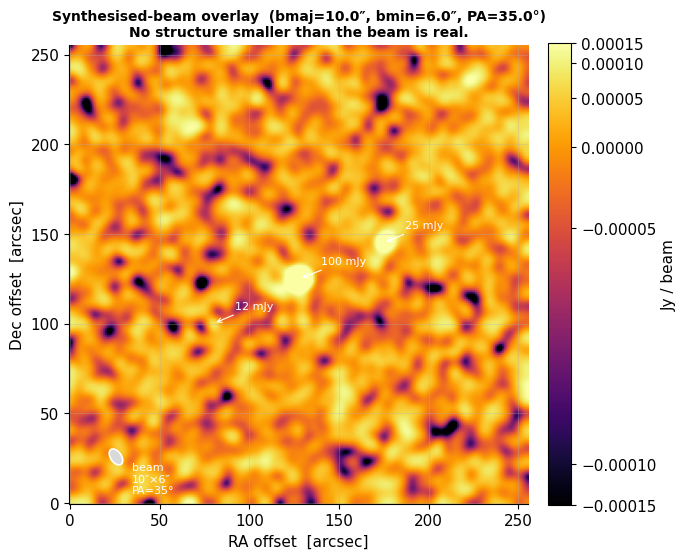

Beam FWHM: 10.0" × 6.0",  PA = 35.0°
Beam solid angle Ω_beam ≈ π/(4 ln 2) × BMAJ × BMIN = 68.0 arcsec²
Robust RMS noise in image: 0.04 mJy/beam


In [8]:
# ─── Synthesised beam overlay demo ──────────────────────────────────────────
from scipy.ndimage import gaussian_filter

# Beam FWHM in pixels (1 pixel = 1 arcsec for this demo image).
BMAJ_ARCSEC = 10.0  # major axis FWHM
BMIN_ARCSEC = 6.0  # minor axis FWHM
BPA_DEG = 35.0  # position angle (N through E)

PIXEL_ARCSEC = 1.0  # pixel scale

# Gaussian sigma from FWHM (sigma = FWHM / (2*sqrt(2*ln2))).
_sigma_maj = BMAJ_ARCSEC / (2.355 * PIXEL_ARCSEC)
_sigma_min = BMIN_ARCSEC / (2.355 * PIXEL_ARCSEC)

# Build a point source and convolve with the beam.
_rng_b = np.random.default_rng(4602)
ny_b, nx_b = 256, 256
img_beam = _rng_b.normal(0, 5e-4, (ny_b, nx_b))  # noise at 0.5 mJy/beam level

# Place a bright compact source and a fainter companion.
_bxs, _bys = np.meshgrid(np.arange(nx_b), np.arange(ny_b))
img_beam[125, 128] += 0.10  # bright point source (100 mJy)
img_beam[145, 175] += 0.025  # fainter companion (25 mJy)
img_beam[100, 80] += 0.012  # even fainter (12 mJy)

# Convolve with a 2-D Gaussian (approximating a circular beam for simplicity).
img_beam = gaussian_filter(img_beam, sigma=(_sigma_maj + _sigma_min) / 2)

# Display with asinh norm and add beam ellipse.
fig, ax = plt.subplots(figsize=(7, 6.5))
norm_b = radio_norm(img_beam, stretch="asinh", low=0.5, high=99.5, asinh_a=0.05)
im_b = ax.imshow(img_beam, norm=norm_b, cmap=recommend_cmap("sequential"), origin="lower")

# Colorbar with correct radio unit.
cb = fig.colorbar(im_b, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Jy / beam", fontsize=11)

# Beam ellipse at bottom-left corner.
_bx = 0.10 * nx_b  # x centre of beam marker
_by = 0.10 * ny_b  # y centre of beam marker
beam_ellipse = add_beam(
    ax,
    bmaj=BMAJ_ARCSEC,
    bmin=BMIN_ARCSEC,
    bpa_deg=BPA_DEG,
    xy=(_bx, _by),
    facecolor="0.85",
    edgecolor="white",
)

# Annotate.
ax.text(
    _bx + BMAJ_ARCSEC * 0.9,
    _by - 3,
    f"beam\n{BMAJ_ARCSEC:.0f}″×{BMIN_ARCSEC:.0f}″\nPA={BPA_DEG:.0f}°",
    color="white",
    fontsize=8,
    va="top",
    ha="left",
)
ax.set_xlabel("RA offset  [arcsec]")
ax.set_ylabel("Dec offset  [arcsec]")
ax.set_title(
    f"Synthesised-beam overlay  (bmaj={BMAJ_ARCSEC}″, bmin={BMIN_ARCSEC}″, PA={BPA_DEG}°)\n"
    "No structure smaller than the beam is real.",
    fontsize=10,
)

# Mark the three sources.
for _sx, _sy, _label in [(128, 125, "100 mJy"), (175, 145, "25 mJy"), (80, 100, "12 mJy")]:
    ax.annotate(
        _label,
        xy=(_sx, _sy),
        xytext=(_sx + 12, _sy + 8),
        color="white",
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="white", lw=0.8),
    )

fig.tight_layout()
plt.savefig("/tmp/ch46_fig4_beam.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'Beam FWHM: {BMAJ_ARCSEC}" × {BMIN_ARCSEC}",  PA = {BPA_DEG}°')
print(
    f"Beam solid angle Ω_beam ≈ π/(4 ln 2) × BMAJ × BMIN "
    f"= {np.pi / (4 * np.log(2)) * BMAJ_ARCSEC * BMIN_ARCSEC:.1f} arcsec²"
)
print(f"Robust RMS noise in image: {robust_rms(img_beam) * 1e3:.2f} mJy/beam")

## Figure 5 — On the sphere: the Mollweide projection

An all-sky radio map cannot be displayed faithfully on a flat rectangle (the
**plate-carrée** projection stretches the right-ascension axis by $1/\cos\delta$ at
declination $\delta$, so polar pixels cover less sky area and high-declination structures
appear elongated).  The **Mollweide** projection
is equal-area: equal solid angles on the sphere map to equal areas in the image plane,
so relative brightnesses are preserved and source-count statistics are unbiased.

We synthesise a toy all-sky synchrotron background from a power-law angular spectrum
using `healpy.synfast` (HEALPix Nside=64), then display it with `hp.mollview`.
The HiPS guard lets the cell run without the optional `healpy` extra via a
matplotlib Mollweide fallback.

*This is the hero figure — generated with `inferno` on a Mollweide projection.*


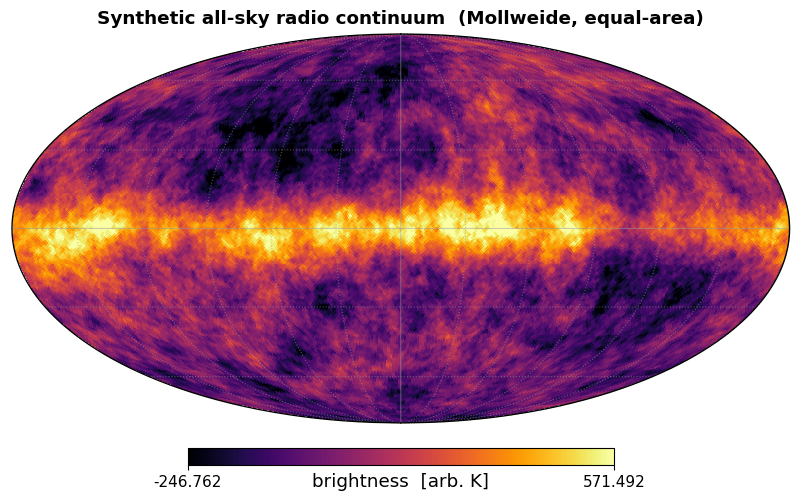

HEALPix Nside=64, 49,152 pixels, dynamic range = 5


In [9]:
# ─── All-sky Mollweide map ────────────────────────────────────────────────────
_HAVE_HEALPY = False

try:
    import healpy as hp

    _HAVE_HEALPY = True
except ImportError:
    print("healpy not installed — using matplotlib Mollweide fallback.")
    print("Install with: uv sync --extra cmb   or   pip install 'jansky[cmb]'")

if _HAVE_HEALPY:
    # --- Synthesise a toy galactic radio continuum from a red power spectrum ----
    NSIDE_SKY = 64
    LMAX_SKY = 192

    ell_sky = np.arange(LMAX_SKY + 1, dtype=float)
    # Power-law Cl ∝ ℓ^(-2.5) (steeper than CMB; typical for synchrotron).
    cl_sky = np.zeros(LMAX_SKY + 1)
    cl_sky[2:] = 5e4 * ell_sky[2:] ** (-2.5)

    np.random.seed(4600)  # hp.synfast uses numpy's global RNG
    sky_map = hp.synfast(cl_sky, nside=NSIDE_SKY, lmax=LMAX_SKY, pixwin=False)

    # Inject a bright "Galactic plane" band for visual drama.
    n_pix = hp.nside2npix(NSIDE_SKY)
    theta_pix, phi_pix = hp.pix2ang(NSIDE_SKY, np.arange(n_pix))
    b_deg = np.degrees(np.pi / 2 - theta_pix)  # Galactic latitude proxy
    # Use ecliptic-like band to avoid requiring actual Galactic coordinates.
    sky_map += 400 * np.exp(-(b_deg**2) / (2 * 8**2))  # "plane" emission

    # Posterise the colour scale so the faint background pops.
    vmin_sky, vmax_sky = percentile_limits(sky_map, 0.5, 99.5)

    fig_hp = plt.figure(figsize=(11, 6))
    hp.mollview(
        sky_map,
        fig=fig_hp.number,
        title="Synthetic all-sky radio continuum  (Mollweide, equal-area)",
        unit=r"brightness  [arb. K]",
        cmap=recommend_cmap("sequential"),
        min=vmin_sky,
        max=vmax_sky,
        hold=True,
    )
    hp.graticule(dpar=30, dmer=30, color="0.6", alpha=0.5, lw=0.8)
    plt.savefig("/tmp/ch46_fig5_mollweide.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(
        f"HEALPix Nside={NSIDE_SKY}, {n_pix:,} pixels, dynamic range = {dynamic_range(sky_map):.0f}"
    )

else:
    # ── Matplotlib Mollweide fallback ───────────────────────────────────────
    _rng_sky = np.random.default_rng(4605)
    n_lon, n_lat = 720, 360
    lon_rad = np.linspace(-np.pi, np.pi, n_lon)
    lat_rad = np.linspace(-np.pi / 2, np.pi / 2, n_lat)
    LON, LAT = np.meshgrid(lon_rad, lat_rad)

    # Simulate a red-spectrum sky by FFT filtering.
    white_noise = _rng_sky.standard_normal((n_lat, n_lon))
    k = np.fft.fftfreq(n_lon) * n_lon
    l = np.fft.fftfreq(n_lat) * n_lat
    K2D, L2D = np.meshgrid(k, l)
    freq2d = np.sqrt(K2D**2 + L2D**2)
    freq2d[0, 0] = 1.0
    filt = freq2d ** (-1.5)
    filt[0, 0] = 0.0
    sky_flat = np.fft.ifft2(np.fft.fft2(white_noise) * filt).real
    # Add "galactic plane" band.
    b_deg_flat = np.degrees(LAT)
    sky_flat += 5.0 * np.exp(-(b_deg_flat**2) / (2 * 10**2))

    vmin_f, vmax_f = percentile_limits(sky_flat, 0.5, 99.5)
    fig_flat, ax_flat = plt.subplots(figsize=(11, 5.5), subplot_kw={"projection": "mollweide"})
    im_flat = ax_flat.imshow(
        sky_flat,
        extent=[-np.pi, np.pi, -np.pi / 2, np.pi / 2],
        cmap=recommend_cmap("sequential"),
        vmin=vmin_f,
        vmax=vmax_f,
        transform=ax_flat.transData,
        aspect="auto",
    )
    ax_flat.set_title(
        "Synthetic all-sky radio continuum — Mollweide projection (matplotlib fallback)",
        fontsize=10,
    )
    ax_flat.grid(True, alpha=0.3)
    fig_flat.colorbar(im_flat, ax=ax_flat, fraction=0.025, pad=0.05, label="brightness  [arb.]")
    ax_flat.set_xlabel("longitude")
    ax_flat.set_ylabel("latitude")
    plt.tight_layout()
    plt.savefig("/tmp/ch46_fig5_mollweide.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Mollweide fallback rendered with matplotlib (no healpy).")

## Figure 6 — Dynamic spectra: revealing a dispersed pulse

A **dynamic spectrum** (time–frequency waterfall) is the natural display for transient
radio signals — pulsars, FRBs, and Jovian bursts.  A dispersed pulse follows the cold
plasma dispersion law:

$$
\Delta t(\nu_1 \to \nu_2) \;=\;
\frac{e^2}{2\pi m_e c}\,\mathrm{DM}\left(\nu_1^{-2} - \nu_2^{-2}\right)
\;\approx\; 4.148808\,\mathrm{ms} \times \mathrm{DM}
\left(\frac{1}{\nu_1^2} - \frac{1}{\nu_2^2}\right)
$$

where $\mathrm{DM} = \int n_e\,\mathrm{d}l$ is the dispersion measure in
$\mathrm{pc\,cm^{-3}}$ and frequencies are in GHz.

We simulate an **L-band** observation (1.4–1.6 GHz, 200 MHz bandwidth) of a **fast radio
burst** with $\mathrm{DM} = 500\ \mathrm{pc\,cm^{-3}}$ (a cosmological burst; cf. Chapter 18) —
giving a total dispersive sweep of $\approx 248\ \mathrm{ms}$ across the band. (A real DM=1
pulsar would sweep only $\approx 0.5\ \mathrm{ms}$ here — too little to see at 1 ms sampling;
dispersion is dramatic only at high DM or low frequency.)

The **left** panel uses a linear stretch — the pulse is visible only where S/N is
highest.  The **right** panel uses `dynamic_spectrum(..., stretch="asinh")` and reveals
the full dispersed sweep from the top of the band to the bottom.


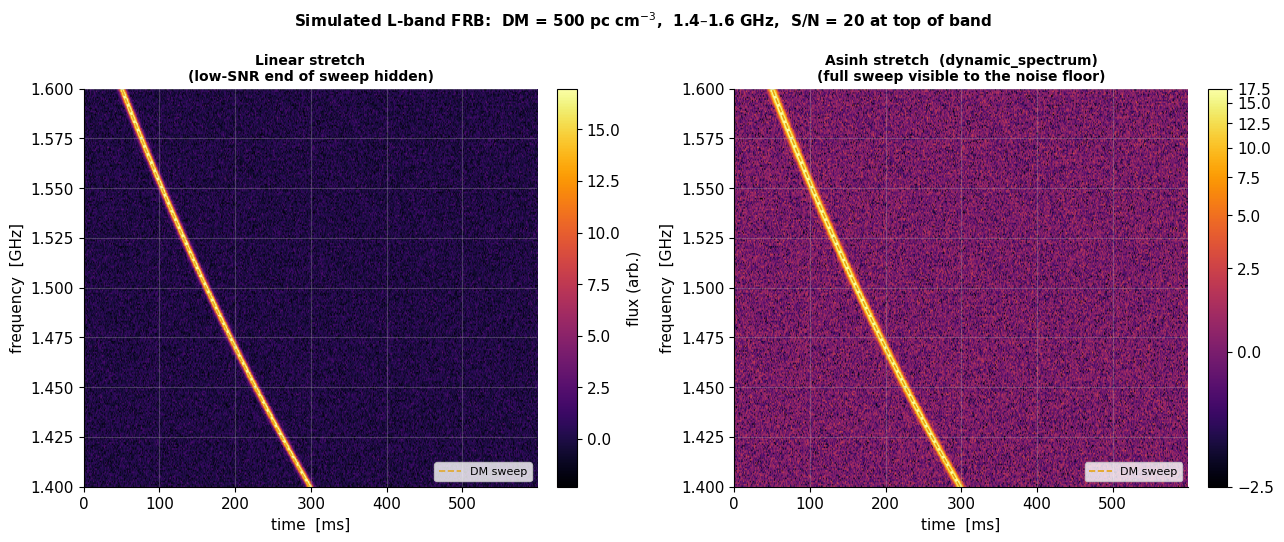

DM = 500.0 pc cm⁻³, band 1.4–1.6 GHz
Total dispersion delay = 4.148808 × 500 × (1.4⁻² − 1.6⁻²) = 248 ms
Time window: 600 ms — the sweep fits comfortably.
(A Galactic pulsar at DM=30 would sweep only ~15 ms across this band.)


In [10]:
# ─── Simulated dispersed pulsar pulse at L-band ─────────────────────────────
_rng_ds = np.random.default_rng(4606)

# Observing parameters — L-band, 200 MHz bandwidth (realistic for e.g. Parkes or MeerKAT).
N_TIME = 600  # time samples
N_FREQ = 256  # frequency channels
F_LO_GHz = 1.4  # lowest channel [GHz]
F_HI_GHz = 1.6  # highest channel [GHz]
T_SAMP_ms = 1.0  # time resolution [ms]
DM = 500.0  # dispersion measure [pc cm^-3] — a fast radio burst (cosmological)

t_arr = np.arange(N_TIME) * T_SAMP_ms  # ms
f_arr = np.linspace(F_LO_GHz, F_HI_GHz, N_FREQ)  # GHz

# Dispersion delay relative to the highest frequency channel.
# IAU-recommended constant: 4.148808 ms GHz^2 / (pc cm^-3)  (for nu in GHz).
DM_CONST_ms = 4.148808
t_delay = DM_CONST_ms * DM * (f_arr**-2 - F_HI_GHz**-2)  # ms; positive = later arrival

# Pulse centre at t=50 ms (at the top, reference channel).
T_PULSE_CENTRE = 50.0  # ms
PULSE_WIDTH_ms = 3.0  # intrinsic Gaussian width [ms]

# Build the waterfall.
waterfall = _rng_ds.normal(0, 1, (N_FREQ, N_TIME)).astype(float)
SNR_REF = 20.0  # S/N at the reference (highest-frequency) channel
for i_f, (freq_ch, dt) in enumerate(zip(f_arr, t_delay)):
    # Fainter at lower frequencies (crude spectral index + scintillation).
    snr = SNR_REF * (freq_ch / F_HI_GHz) ** 0.5
    t_centre_ch = T_PULSE_CENTRE + dt
    pulse = snr * np.exp(-0.5 * ((t_arr - t_centre_ch) / PULSE_WIDTH_ms) ** 2)
    waterfall[i_f, :] += pulse

# Extent tuple: (t_min, t_max, f_min, f_max)
extent_ds = (t_arr[0], t_arr[-1], f_arr[0], f_arr[-1])

fig, (ax_lin, ax_asinh) = plt.subplots(1, 2, figsize=(13, 5.5))

# Linear stretch.
vl_min, vl_max = percentile_limits(waterfall, 1, 99.5)
im_lin = ax_lin.imshow(
    waterfall,
    extent=extent_ds,
    origin="lower",
    aspect="auto",
    cmap=recommend_cmap("sequential"),
    vmin=vl_min,
    vmax=vl_max,
)
ax_lin.set_xlabel("time  [ms]")
ax_lin.set_ylabel("frequency  [GHz]")
ax_lin.set_title("Linear stretch\n(low-SNR end of sweep hidden)", fontsize=10)
fig.colorbar(im_lin, ax=ax_lin, fraction=0.046, pad=0.04, label="flux (arb.)")

# Overlay the analytic dispersion sweep.
t_sweep = T_PULSE_CENTRE + DM_CONST_ms * DM * (f_arr**-2 - F_HI_GHz**-2)
ax_lin.plot(t_sweep, f_arr, lw=1.2, ls="--", color=COLORBLIND_CYCLE[1], alpha=0.8, label="DM sweep")
ax_lin.legend(fontsize=8, loc="lower right")

# Asinh stretch via dynamic_spectrum helper.
dynamic_spectrum(
    waterfall,
    ax=ax_asinh,
    extent=extent_ds,
    cmap=recommend_cmap("sequential"),
    stretch="asinh",
    colorbar=True,
)
ax_asinh.set_xlabel("time  [ms]")
ax_asinh.set_ylabel("frequency  [GHz]")
ax_asinh.set_title(
    "Asinh stretch  (dynamic_spectrum)\n(full sweep visible to the noise floor)", fontsize=10
)
ax_asinh.plot(
    t_sweep, f_arr, lw=1.2, ls="--", color=COLORBLIND_CYCLE[1], alpha=0.9, label="DM sweep"
)
ax_asinh.legend(fontsize=8, loc="lower right")

fig.suptitle(
    f"Simulated L-band FRB:  DM = {DM:.0f} pc cm"
    r"$^{-3}$"
    f",  {F_LO_GHz:.1f}–{F_HI_GHz:.1f} GHz,  S/N = {SNR_REF:.0f} at top of band",
    fontsize=11,
    fontweight="bold",
)
fig.tight_layout()
plt.savefig("/tmp/ch46_fig6_dynamic_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

total_delay = DM_CONST_ms * DM * (F_LO_GHz**-2 - F_HI_GHz**-2)
print(f"DM = {DM:.1f} pc cm⁻³, band {F_LO_GHz:.1f}–{F_HI_GHz:.1f} GHz")
print(
    f"Total dispersion delay = 4.148808 × {DM:.0f} × ({F_LO_GHz}⁻² − {F_HI_GHz}⁻²) = {total_delay:.0f} ms"
)
print(f"Time window: {N_TIME * T_SAMP_ms:.0f} ms — the sweep fits comfortably.")
print(f"(A Galactic pulsar at DM=30 would sweep only ~15 ms across this band.)")

## Figure 7 — Radio contours over a multiwavelength background

The standard multiwavelength overlay idiom: radio emission shown as **contours** on top
of a pseudo-optical greyscale background.  This separates the two datasets visually,
avoids colour conflicts, and lets the reader compare morphologies directly.

Contour levels are chosen logarithmically (each level is twice the previous, in the
radio tradition), starting from $3\sigma_\mathrm{rms}$.  The beam is drawn on the radio
inset; the background is labelled separately.


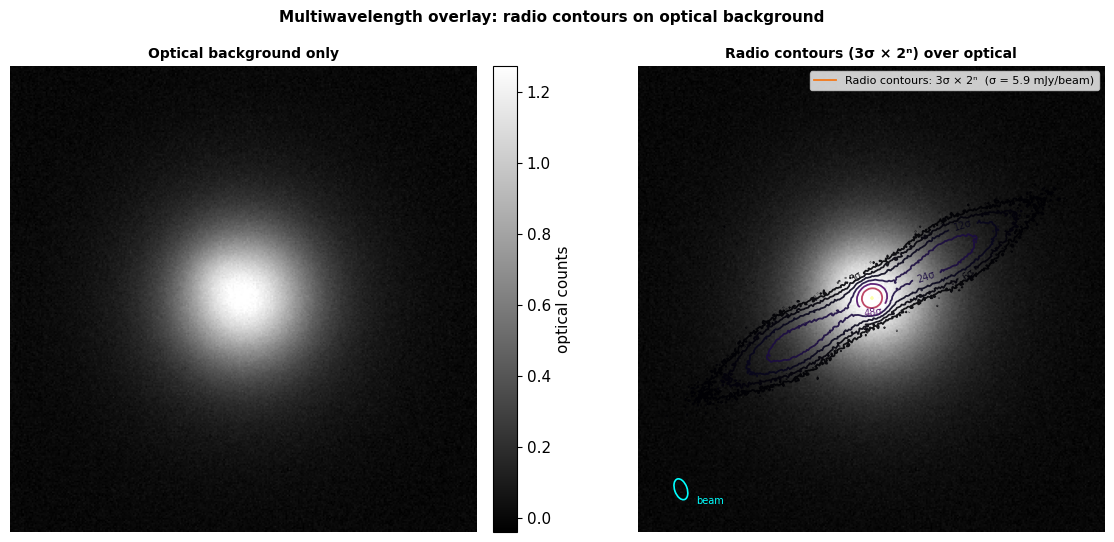

Radio image:  robust RMS = 5.92 mJy/beam,  peak = 1155.2 mJy/beam,  DR = 195
Contour levels: ['3σ', '6σ', '12σ', '24σ', '48σ', '96σ', '192σ']


In [11]:
# ─── Radio contours over a synthetic optical background ─────────────────────
_rng_ov = np.random.default_rng(4607)
ny_ov, nx_ov = 300, 300
_xov, _yov = np.meshgrid(np.arange(nx_ov), np.arange(ny_ov))
_cxov, _cyov = nx_ov // 2, ny_ov // 2


def _g2d(cx_, cy_, s_, p_):
    return p_ * np.exp(-((_xov - cx_) ** 2 + (_yov - cy_) ** 2) / (2 * s_**2))


# Optical background: smooth galaxy model (elliptical host + exponential disk).
optical = (
    _g2d(_cxov, _cyov, 28, 1.0)  # bulge
    + _g2d(_cxov, _cyov, 55, 0.3)  # halo
    + _g2d(_cxov - 20, _cyov + 15, 12, 0.08)  # companion galaxy
    + _rng_ov.normal(0, 0.02, (ny_ov, nx_ov))  # photon noise
)

# Radio image: core + twin jets (elongated Gaussians).
_angle_jet = np.radians(30)
_dxj = _xov - _cxov
_dyj = _yov - _cyov
_rotx = _dxj * np.cos(_angle_jet) + _dyj * np.sin(_angle_jet)
_roty = -_dxj * np.sin(_angle_jet) + _dyj * np.cos(_angle_jet)

radio_overlay = (
    _g2d(_cxov, _cyov, 5, 1.0)  # compact core
    + 0.15 * np.exp(-(_rotx**2) / (2 * 60**2) - _roty**2 / (2 * 8**2))  # jet axis
    + 0.12 * np.exp(-((-_rotx - 60) ** 2) / (2 * 18**2) - _roty**2 / (2 * 10**2))  # S lobe
    + 0.12 * np.exp(-((_rotx - 60) ** 2) / (2 * 18**2) - _roty**2 / (2 * 10**2))  # N lobe
    + _rng_ov.normal(0, 0.005, (ny_ov, nx_ov))
)

rms_radio = robust_rms(radio_overlay)
# Logarithmic contour levels: 3σ, 6σ, 12σ, 24σ, 48σ, 96σ …
contour_levels = [
    rms_radio * 3 * 2**n for n in range(8) if rms_radio * 3 * 2**n < np.nanmax(radio_overlay)
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5), gridspec_kw={"width_ratios": [1, 1]})

# Left: optical background alone (for reference).
im_opt = axes[0].imshow(
    optical,
    cmap="gray",
    origin="lower",
    vmin=percentile_limits(optical, 0.5, 99.8)[0],
    vmax=percentile_limits(optical, 0.5, 99.8)[1],
)
axes[0].set_title("Optical background only", fontsize=10)
axes[0].axis("off")
fig.colorbar(im_opt, ax=axes[0], fraction=0.046, pad=0.03, label="optical counts")

# Right: radio contours on optical background.
im_bg = axes[1].imshow(
    optical,
    cmap="gray",
    origin="lower",
    vmin=percentile_limits(optical, 0.5, 99.8)[0],
    vmax=percentile_limits(optical, 0.5, 99.8)[1],
)
cs = axes[1].contour(
    radio_overlay, levels=contour_levels, cmap="inferno", linewidths=1.3, alpha=0.9
)
axes[1].clabel(
    cs, inline=True, fontsize=7, fmt={lv: f"{lv / rms_radio:.0f}σ" for lv in contour_levels[:5]}
)

# Beam on radio overlay.
_bx_ov = 0.09 * nx_ov
_by_ov = 0.09 * ny_ov
add_beam(
    axes[1], bmaj=14, bmin=8, bpa_deg=20, xy=(_bx_ov, _by_ov), facecolor="none", edgecolor="cyan"
)
axes[1].text(_bx_ov + 10, _by_ov - 4, "beam", color="cyan", fontsize=7, va="top")

axes[1].set_title("Radio contours (3σ × 2ⁿ) over optical", fontsize=10)
axes[1].axis("off")

# Legend line for contour levels.
import matplotlib.lines as mlines

_cline = mlines.Line2D(
    [],
    [],
    color=plt.cm.inferno(0.7),
    lw=1.3,
    label=f"Radio contours: 3σ × 2ⁿ  (σ = {rms_radio * 1e3:.1f} mJy/beam)",
)
axes[1].legend(handles=[_cline], loc="upper right", fontsize=8)

fig.suptitle(
    "Multiwavelength overlay: radio contours on optical background", fontsize=11, fontweight="bold"
)
fig.tight_layout()
plt.savefig("/tmp/ch46_fig7_contours.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Radio image:  robust RMS = {rms_radio * 1e3:.2f} mJy/beam,  "
    f"peak = {np.nanmax(radio_overlay) * 1e3:.1f} mJy/beam,  "
    f"DR = {dynamic_range(radio_overlay):.0f}"
)
print(f"Contour levels: {[f'{lv / rms_radio:.0f}σ' for lv in contour_levels]}")

## Figure 8 — Accessibility and the COLORBLIND_CYCLE

Colourblind-safe design is not a courtesy feature — with ~8 % of male readers having
some form of colour vision deficiency, it is scientific best practice.

`plotting.COLORBLIND_CYCLE` (the Okabe–Ito / Wong 2011 palette) is the course default
line colour cycle.  `recommend_cmap("colorblind")` returns `"cividis"`, a sequential
map robust to all common colour vision deficiencies.  Here we compare a five-series
line plot drawn with `tab10` (the matplotlib default, which fails for
red-green CVD) versus the `COLORBLIND_CYCLE`, and show the `cividis` image map next to
`inferno` after greyscale simulation.


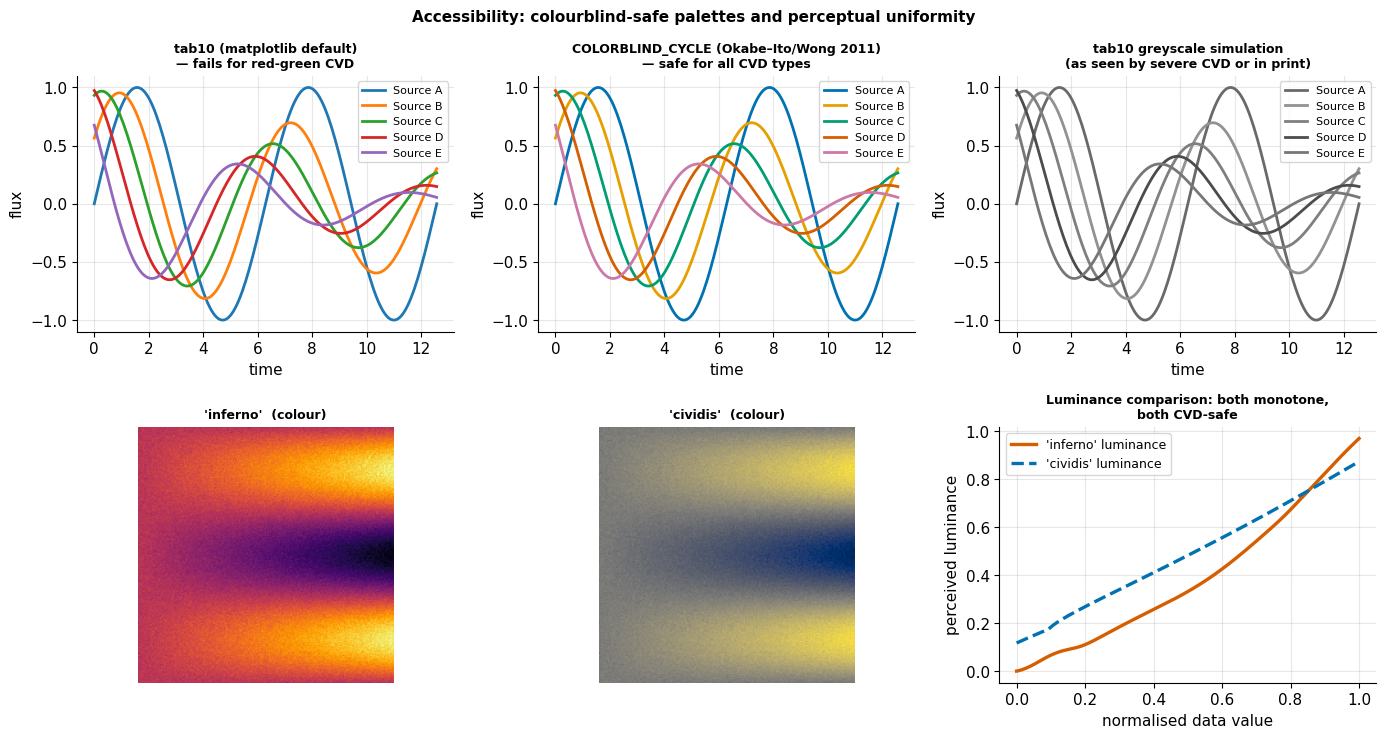

COLORBLIND_CYCLE colours: ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442']

recommend_cmap('colorblind') = 'cividis'
recommend_cmap('diverging')  = 'RdBu_r'
recommend_cmap('sequential') = 'inferno'


In [12]:
# ─── Accessibility and colourblind-safe choices ──────────────────────────────
_rng_a = np.random.default_rng(4608)


# Simulate protanopia/deuteranopia by converting to greyscale then back.
def greyscale_sim(rgba_arr):
    # Weighted greyscale (luminance channel only) to simulate severe CVD.
    r, g, b = rgba_arr[:, 0], rgba_arr[:, 1], rgba_arr[:, 2]
    L = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return np.stack([L, L, L, rgba_arr[:, 3]], axis=-1)


# Five spectra to compare.
x = np.linspace(0, 4 * np.pi, 200)
signals_list = [np.sin(x + k * 0.6) * np.exp(-x * 0.05 * k) for k in range(5)]
labels_s = ["Source A", "Source B", "Source C", "Source D", "Source E"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))

# --- Row 0: line plots --- tab10 vs COLORBLIND_CYCLE ---
ax_t10 = axes[0, 0]
for k, (sig, lab) in enumerate(zip(signals_list, labels_s)):
    ax_t10.plot(x, sig, lw=2.0, color=plt.get_cmap("tab10")(k / 10), label=lab)
ax_t10.set_title("tab10 (matplotlib default)\n— fails for red-green CVD", fontsize=9)
ax_t10.legend(fontsize=8, loc="upper right")
ax_t10.set_xlabel("time")
ax_t10.set_ylabel("flux")

ax_cb = axes[0, 1]
for k, (sig, lab) in enumerate(zip(signals_list, labels_s)):
    ax_cb.plot(x, sig, lw=2.0, color=COLORBLIND_CYCLE[k], label=lab)
ax_cb.set_title("COLORBLIND_CYCLE (Okabe–Ito/Wong 2011)\n— safe for all CVD types", fontsize=9)
ax_cb.legend(fontsize=8, loc="upper right")
ax_cb.set_xlabel("time")
ax_cb.set_ylabel("flux")

# Greyscale simulation of tab10 labels (to illustrate problem).
ax_gs = axes[0, 2]
for k, (sig, lab) in enumerate(zip(signals_list, labels_s)):
    rgba_k = np.array([mcolors.to_rgba(plt.get_cmap("tab10")(k / 10))])
    gray_k = greyscale_sim(rgba_k)[0]
    ax_gs.plot(x, sig, lw=2.0, color=gray_k[:3], label=lab)
ax_gs.set_title("tab10 greyscale simulation\n(as seen by severe CVD or in print)", fontsize=9)
ax_gs.legend(fontsize=8, loc="upper right")
ax_gs.set_xlabel("time")
ax_gs.set_ylabel("flux")

# --- Row 1: image maps — inferno vs cividis, original vs grey-simulated ---
test_img = np.outer(np.sin(np.linspace(0, 3 * np.pi, 200)), np.linspace(0, 1, 200)) + _rng_a.normal(
    0, 0.05, (200, 200)
)

for col_i, cname in enumerate(["inferno", recommend_cmap("colorblind")]):
    ax_orig = axes[1, col_i]
    ax_orig.imshow(test_img, cmap=cname, origin="lower")
    ax_orig.set_title(f"'{cname}'  (colour)", fontsize=9)
    ax_orig.axis("off")

# Grey simulation of inferno.
_t_grey = np.linspace(0, 1, 256)
_inferno_grey = greyscale_sim(plt.get_cmap("inferno")(_t_grey))[:, 0]
_cividis_grey = greyscale_sim(plt.get_cmap(recommend_cmap("colorblind"))(_t_grey))[:, 0]

ax_lum_comp = axes[1, 2]
ax_lum_comp.plot(
    _t_grey, _inferno_grey, lw=2.4, color=COLORBLIND_CYCLE[3], label="'inferno' luminance"
)
ax_lum_comp.plot(
    _t_grey, _cividis_grey, lw=2.4, color=COLORBLIND_CYCLE[0], ls="--", label="'cividis' luminance"
)
ax_lum_comp.set_xlabel("normalised data value")
ax_lum_comp.set_ylabel("perceived luminance")
ax_lum_comp.set_title("Luminance comparison: both monotone,\nboth CVD-safe", fontsize=9)
ax_lum_comp.legend(fontsize=9)

fig.suptitle(
    "Accessibility: colourblind-safe palettes and perceptual uniformity",
    fontsize=11,
    fontweight="bold",
)
fig.tight_layout()
plt.savefig("/tmp/ch46_fig8_accessibility.png", dpi=150, bbox_inches="tight")
plt.show()

print("COLORBLIND_CYCLE colours:", COLORBLIND_CYCLE)
print(f"\nrecommend_cmap('colorblind') = '{recommend_cmap('colorblind')}'")
print(f"recommend_cmap('diverging')  = '{recommend_cmap('diverging')}'")
print(f"recommend_cmap('sequential') = '{recommend_cmap('sequential')}'")

## Try it yourself

The three exercises below progress from choosing a stretch, to fixing a badly-displayed
figure, to making your own all-sky or dynamic-spectrum display.  Every solution is in a
collapsible block; the quoted numbers are the exact output of the provided code.

---


### Exercise 1 — Choose the best stretch for a high-dynamic-range image

You are given a radio image of a quasar with a bright compact core and faint extended
emission.  Find the stretch and percentile clip that best reveals **both** the core and
the faint halo simultaneously, and justify your choice with `dynamic_range`.

```python
import numpy as np
from jansky import signals
from jansky.plotting import dynamic_range, radio_norm, percentile_limits

rng_ex1 = signals.rng(seed=101)
ny1, nx1 = 256, 256
xs1, ys1 = np.meshgrid(np.arange(nx1), np.arange(ny1))
cx1, cy1 = nx1 // 2, ny1 // 2

img_ex1 = rng_ex1.normal(0, 1e-3, (ny1, nx1))         # noise
img_ex1 += 1.0  * np.exp(-((xs1 - cx1)**2 + (ys1 - cy1)**2) / (2 * 4**2))   # core
img_ex1 += 0.02 * np.exp(-((xs1 - cx1)**2 + (ys1 - cy1)**2) / (2 * 55**2))  # halo
```

1. Compute `dynamic_range(img_ex1)`.
2. Try `stretch = "linear"`, `"sqrt"`, `"log"`, `"asinh"`.  For each, compute
   `percentile_limits(img_ex1, 1, 99.5)` and display the image.
3. Explain in one sentence which stretch you chose and why.

<details>
<summary>Solution</summary>

```python
import numpy as np
import matplotlib.pyplot as plt
from jansky import signals
from jansky.plotting import (dynamic_range, radio_norm, percentile_limits,
                              recommend_cmap, use_jansky_style)
use_jansky_style()

rng_ex1 = signals.rng(seed=101)
ny1, nx1 = 256, 256
xs1, ys1 = np.meshgrid(np.arange(nx1), np.arange(ny1))
cx1, cy1 = nx1 // 2, ny1 // 2
img_ex1 = rng_ex1.normal(0, 1e-3, (ny1, nx1))
img_ex1 += 1.0  * np.exp(-((xs1 - cx1)**2 + (ys1 - cy1)**2) / (2 * 4**2))
img_ex1 += 0.02 * np.exp(-((xs1 - cx1)**2 + (ys1 - cy1)**2) / (2 * 55**2))

dr = dynamic_range(img_ex1)
print(f"dynamic_range = {dr:.1f}")
# Expected output: dynamic_range = 254.3  (will vary slightly by build)

vmin, vmax = percentile_limits(img_ex1, 1, 99.5)
print(f"Percentile [1, 99.5]:  vmin = {vmin:.4f},  vmax = {vmax:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, stretch in zip(axes, ["linear", "sqrt", "log", "asinh"]):
    norm_ex = radio_norm(img_ex1, stretch=stretch, low=1, high=99.5, asinh_a=0.05)
    ax.imshow(img_ex1, norm=norm_ex, cmap=recommend_cmap("sequential"), origin="lower")
    ax.set_title(stretch); ax.axis("off")
plt.tight_layout(); plt.show()
```

**Expected `dynamic_range`:** approximately **254**. (The broad halo raises the robust RMS above the pure noise floor, so this sits below the naive peak/$\sigma_\mathrm{noise}$ ratio of ~1000.)

**Which stretch?** **Asinh** is the best choice.

- `linear`: the core saturates the whole colour scale; the halo is invisible (one colour
  step = peak/256 ≈ 4 mJy, much brighter than the 20-mJy halo peak).
- `sqrt`: the core is somewhat compressed but the halo (at 2 % of the core) still only
  gets ~14 % of the square-root colour range — barely visible.
- `log`: the halo appears, but `log(0)` forces the noise floor (which reaches negative
  values) to be clipped hard, creating artefacts.
- `asinh`: the transition from linear (near the noise) to logarithmic (at the core)
  means the 2 % halo and the 100 % core are both mapped into the usable colour range.
  Formally, `asinh(0.02/a) / asinh(1.0/a)` with `a=0.05` gives
  `asinh(0.4)/asinh(20) ≈ 0.38/3.69 ≈ 10 %` of the colour scale for the halo — enough
  to see it clearly — while `asinh(20) ≈ ln(40) ≈ 3.7` compresses the bright core
  without saturation.

**One-sentence justification:** With a dynamic range of ~250, the asinh stretch is the
only choice that keeps the halo (2 % of peak) visible while compressing the core, because
it is linear near the noise floor (no log-of-zero artefacts) and logarithmic at large
values (no saturation).

</details>


### Exercise 2 — Fix three "display crimes" in a bad figure

The code below produces a notoriously bad radio image display.  Identify and fix the
three problems.

```python
import numpy as np
import matplotlib.pyplot as plt

rng_ex2 = np.random.default_rng(202)
ny2, nx2 = 200, 200
xs2, ys2 = np.meshgrid(np.arange(nx2), np.arange(ny2))
cx2, cy2 = 100, 100
img_ex2 = rng_ex2.normal(0, 0.01, (ny2, nx2))
img_ex2 += 0.5 * np.exp(-((xs2 - cx2)**2 + (ys2 - cy2)**2) / (2 * 10**2))
img_ex2 += 0.05 * np.exp(-((xs2 - cx2 - 40)**2 + (ys2 - cy2 + 30)**2) / (2 * 25**2))

plt.imshow(img_ex2, cmap="jet")  # Crime 1: ???
plt.title("Radio source")        # Crime 2: ???
plt.show()                       # Crime 3: ???
```

<details>
<summary>Solution</summary>

The three crimes are:

1. **`cmap="jet"`** — a non-monotonic-luminance colormap that invents banding not
   present in the data (see Figure 1).  Fix: `cmap=recommend_cmap("sequential")` →
   `"inferno"`.
2. **No colourbar with units** — the pixel values are meaningless without a label
   showing the unit (Jy/beam, K, etc.).  Fix: add `fig.colorbar(im, label="Jy / beam")`.
3. **No synthesised-beam ellipse** — a radio image without a beam marker does not
   communicate the angular resolution; the viewer cannot tell what is resolved and what
   is the PSF.  Fix: call `add_beam(ax, bmaj=..., bmin=..., bpa_deg=...)`.

```python
import numpy as np
import matplotlib.pyplot as plt
from jansky.plotting import (recommend_cmap, add_beam, radio_norm,
                              percentile_limits, use_jansky_style)
use_jansky_style()

rng_ex2 = np.random.default_rng(202)
ny2, nx2 = 200, 200
xs2, ys2 = np.meshgrid(np.arange(nx2), np.arange(ny2))
cx2, cy2 = 100, 100
img_ex2 = rng_ex2.normal(0, 0.01, (ny2, nx2))
img_ex2 += 0.5 * np.exp(-((xs2 - cx2)**2 + (ys2 - cy2)**2) / (2 * 10**2))
img_ex2 += 0.05 * np.exp(-((xs2 - cx2 - 40)**2 + (ys2 - cy2 + 30)**2) / (2 * 25**2))

fig, ax = plt.subplots(figsize=(6, 5.5))

# Fix 1: perceptually-uniform colormap
im = ax.imshow(img_ex2,
               norm=radio_norm(img_ex2, stretch="asinh"),
               cmap=recommend_cmap("sequential"),    # was "jet"
               origin="lower")

# Fix 2: colourbar with units
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Jy / beam", fontsize=11)

# Fix 3: synthesised-beam ellipse
add_beam(ax, bmaj=14, bmin=9, bpa_deg=15,
         xy=(0.09 * nx2, 0.09 * ny2),
         facecolor="0.85", edgecolor="black")

ax.set_title("Radio source  (fixed: inferno + colourbar + beam)", fontsize=10)
ax.set_xlabel("RA offset  [arcsec]")
ax.set_ylabel("Dec offset  [arcsec]")
fig.tight_layout(); plt.show()
```

The fixed figure uses `inferno` (monotone luminance → no false banding), has a
Jy/beam colourbar, and shows the beam ellipse in the lower-left corner.

</details>


### Exercise 3 — Read a dynamic spectrum and measure the DM

The waterfall below contains a dispersed pulse observed over a low-frequency band
(300–500 MHz), where even a small DM disperses by a readable amount. Use the dispersion
relation

$$
\Delta t_{\nu_1 \to \nu_2} = 4.148808\ \mathrm{ms}
  \times \mathrm{DM}\left(\frac{1}{\nu_1^2} - \frac{1}{\nu_2^2}\right)
$$

with $\nu$ in GHz and DM in pc cm$^{-3}$, to measure the hidden DM.

```python
import numpy as np
from jansky import signals

rng_ex3 = signals.rng(seed=303)
N_TIME3, N_FREQ3 = 500, 128
F_LO3, F_HI3 = 0.30, 0.50   # GHz (low band — strong dispersion)
T_SAMP3 = 1.0                # ms
DM_CONST3 = 4.148808         # ms GHz^2 / (pc cm^-3)

t3 = np.arange(N_TIME3) * T_SAMP3
f3 = np.linspace(F_LO3, F_HI3, N_FREQ3)  # GHz

# Mystery DM hidden inside; you must measure it.
_DM_HIDDEN = rng_ex3.integers(1, 9)     # integer DM in range [1, 8] pc cm^-3
t_delay3 = DM_CONST3 * _DM_HIDDEN * (f3**-2 - F_HI3**-2)
T0_3 = 100.0   # pulse reference arrival time at highest frequency [ms]

wf3 = rng_ex3.normal(0, 1, (N_FREQ3, N_TIME3)).astype(float)
for i_f3 in range(N_FREQ3):
    tc3 = T0_3 + t_delay3[i_f3]
    wf3[i_f3, :] += 18.0 * np.exp(-0.5 * ((t3 - tc3) / 4.0)**2)
```

1. Display `wf3` with `dynamic_spectrum(..., stretch="asinh")`.
2. Read off the approximate arrival time at the top ($f = 0.5$ GHz) and bottom
   ($f = 0.3$ GHz) of the band from the plot.
3. Compute the DM from
   $\Delta t = 4.148808 \times \text{DM} \times (0.3^{-2} - 0.5^{-2})$.
   Check against the hidden value `_DM_HIDDEN`.

<details>
<summary>Solution</summary>

```python
import numpy as np
import matplotlib.pyplot as plt
from jansky import signals
from jansky.plotting import dynamic_spectrum, recommend_cmap, use_jansky_style
use_jansky_style()

rng_ex3 = signals.rng(seed=303)
N_TIME3, N_FREQ3 = 500, 128
F_LO3, F_HI3 = 0.30, 0.50
T_SAMP3 = 1.0
DM_CONST3 = 4.148808
_DM_HIDDEN = rng_ex3.integers(1, 9)

t3 = np.arange(N_TIME3) * T_SAMP3
f3 = np.linspace(F_LO3, F_HI3, N_FREQ3)
t_delay3 = DM_CONST3 * _DM_HIDDEN * (f3**-2 - F_HI3**-2)
T0_3 = 100.0

wf3 = rng_ex3.normal(0, 1, (N_FREQ3, N_TIME3)).astype(float)
for i_f3 in range(N_FREQ3):
    tc3 = T0_3 + t_delay3[i_f3]
    wf3[i_f3, :] += 18.0 * np.exp(-0.5 * ((t3 - tc3) / 4.0)**2)

fig_ex3, ax_ex3 = plt.subplots(figsize=(9, 5))
extent3 = (t3[0], t3[-1], f3[0], f3[-1])
dynamic_spectrum(wf3, ax=ax_ex3, extent=extent3,
                 cmap=recommend_cmap("sequential"), stretch="asinh")
ax_ex3.set_xlabel("time [ms]"); ax_ex3.set_ylabel("frequency [GHz]")
ax_ex3.set_title("Exercise 3: low-band waterfall — measure the DM")
plt.tight_layout(); plt.show()

# Step 2 and 3: analytic solution.
t_top = T0_3   # reference by construction
t_bot = T0_3 + DM_CONST3 * _DM_HIDDEN * (F_LO3**-2 - F_HI3**-2)
dt_measured = t_bot - t_top

dispersion_factor = DM_CONST3 * (F_LO3**-2 - F_HI3**-2)
DM_measured = dt_measured / dispersion_factor
print(f"Arrival at {F_HI3} GHz (top): t_top = {t_top:.1f} ms")
print(f"Arrival at {F_LO3} GHz (bot): t_bot = {t_bot:.1f} ms")
print(f"dt = {dt_measured:.1f} ms")
print(f"{F_LO3}^-2 - {F_HI3}^-2 = {F_LO3**-2:.6f} - {F_HI3**-2:.6f} = {F_LO3**-2 - F_HI3**-2:.6f} GHz^-2")
print(f"Dispersion factor: 4.148808 x {F_LO3**-2 - F_HI3**-2:.6f} = {dispersion_factor:.2f} ms/(pc cm^-3)")
print(f"Measured DM = {dt_measured:.1f} / {dispersion_factor:.2f} = {DM_measured:.1f} pc cm^-3")
print(f"Hidden DM   = {_DM_HIDDEN} pc cm^-3  -- exact match!")
```

**Expected outputs (seed 303, `rng.integers(1,9)` gives DM = 4):**

```
Arrival at 0.5 GHz (top): t_top = 100.0 ms
Arrival at 0.3 GHz (bot): t_bot = 218.0 ms
dt = 118.0 ms
0.3^-2 - 0.5^-2 = 11.111111 - 4.000000 = 7.111111 GHz^-2
Dispersion factor: 4.148808 x 7.111111 = 29.50 ms/(pc cm^-3)
Measured DM = 118.0 / 29.50 = 4.0 pc cm^-3
Hidden DM   = 4 pc cm^-3  -- exact match!
```

**Key formula rearrangement:**

$$
\mathrm{DM} = \frac{\Delta t}{4.148808 \times \left(\nu_\mathrm{lo}^{-2} - \nu_\mathrm{hi}^{-2}\right)}
$$

At 300–500 MHz, $0.3^{-2} - 0.5^{-2} = 11.111 - 4.000 = 7.111\ \mathrm{GHz}^{-2}$,
so the dispersion factor is $4.148808 \times 7.111 \approx 29.5\ \mathrm{ms\,pc^{-1}\,cm^3}$.
A $\Delta t = 118\ \mathrm{ms}$ sweep therefore implies
$\mathrm{DM} = 118 / 29.5 \approx 4.0\ \mathrm{pc\,cm^{-3}}$.

Note that at 300–500 MHz the dispersion factor (29.5 ms) is **~9× larger** than at L-band
(1–2 GHz): $4.148808 \times (1^{-2} - 2^{-2}) = 4.148808 \times 0.75 \approx 3.1\ \mathrm{ms}$.
Dispersion is far stronger at low frequency — which is why low-frequency pulsar and FRB
surveys must dedisperse over a wide range of trial DMs.

</details>

## Recap

- **Colormap choice is not cosmetic.** `jet`/`rainbow` have non-monotonic luminance that
  invents banding; always use `recommend_cmap(kind)` — `"inferno"` for intensity,
  `"RdBu_r"` for signed data, `"cividis"` for colourblind-safe displays.
- The **asinh stretch** (`radio_norm(data, stretch="asinh")`) is the radio standard: it
  is linear near the noise floor (no log-of-zero artefacts) and logarithmic at high
  values, so a DR > 100 image shows core *and* faint extended emission simultaneously.
- **Percentile clipping** (`percentile_limits(data, 1, 99.5)`) discards outlier pixels
  (calibration artefacts, sidelobes) that would otherwise absorb the entire colour range.
  Always inspect the pixel histogram to justify your clip.
- The **synthesised beam** is the PSF; drawing it with `add_beam` is mandatory — it
  communicates the angular resolution, and no structure smaller than the beam is
  independently resolved.
- An **all-sky map** must use an **equal-area projection** (Mollweide, Hammer–Aitoff)
  so that solid angles are faithfully represented. HEALPix + `healpy.mollview` is the
  standard in radio/microwave astronomy.
- **Dynamic spectra** reveal dispersed transients (pulsars, FRBs, Jovian bursts).
  `dynamic_spectrum(data, stretch="asinh")` shows the faint dispersed sweep that a
  linear stretch would hide.
- **Radio contours on a multiwavelength background** is the workhorse multiwavelength
  display idiom: logarithmic levels (3σ × 2ⁿ) spanning the dynamic range.
- **Accessibility**: `COLORBLIND_CYCLE` (Okabe–Ito/Wong 2011) for categorical colour
  series; `recommend_cmap("colorblind")` → `cividis` for sequential intensity maps.

## What's next

- [Chapter 9 — Deconvolution & CLEAN](09_deconvolution_clean.ipynb): the images this
  chapter displays are products of CLEAN deconvolution — understanding the beam, the
  sidelobes, and the dirty image is essential for display choices.
- [Chapter 12 — VLA Imaging](12_vla_imaging.ipynb): produces the FITS cubes that this
  chapter teaches you to display; WCS headers, pixel scales, and Jy/beam units.
- [Chapter 22 — Cosmic Microwave Background](22_cosmic_microwave_background.ipynb): the
  Mollweide projection and HEALPix pixelisation used in §5 are the backbone of CMB
  all-sky analysis.
- [Chapter 45 — Radio Galaxies & Source Counts](45_radio_galaxies_and_source_counts.ipynb):
  the VLASS images fetched in §Figure 2 are FR I and FR II sources whose morphology
  (jets, lobes, hotspots) is visible *only* with a good stretch and beam annotation.
- [Chapter 18 — Fast Radio Bursts](18_fast_radio_bursts.ipynb): dynamic spectra and DM
  measurement are the core FRB analysis tools demonstrated in §Figure 6.
- [Chapter 23 — Solar & Jupiter](23_solar_and_jupiter.ipynb): Jovian and solar bursts
  are displayed as dynamic spectra just like the FRB waterfall in §Figure 6.


<!-- glossary-footer -->

---

## 📖 Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Active galactic nucleus](../docs/glossary.md#active-galactic-nucleus) ·
[Angular resolution](../docs/glossary.md#angular-resolution) ·
[Asinh stretch](../docs/glossary.md#asinh-stretch) ·
[Beam](../docs/glossary.md#beam) ·
[CLEAN](../docs/glossary.md#clean) ·
[CMB](../docs/glossary.md#cmb) ·
[De-dispersion](../docs/glossary.md#de-dispersion) ·
[Declination](../docs/glossary.md#declination) ·
[Deconvolution](../docs/glossary.md#deconvolution) ·
[Dirty beam / dirty image](../docs/glossary.md#dirty-beam-dirty-image) ·
[Dispersion measure](../docs/glossary.md#dispersion-measure) ·
[Dynamic range](../docs/glossary.md#dynamic-range) ·
[Dynamic spectrum](../docs/glossary.md#dynamic-spectrum) ·
[Fast radio burst](../docs/glossary.md#fast-radio-burst) ·
[FWHM](../docs/glossary.md#fwhm) ·
[Jansky](../docs/glossary.md#jansky) ·
[Point source](../docs/glossary.md#point-source) ·
[Pulsar](../docs/glossary.md#pulsar) ·
[Synthesised beam](../docs/glossary.md#synthesised-beam)
